In [ ]:
# Vehicle counter (virtual counting lines, centroid tracker, direction detection)
# Usage: instantiate VehicleCounter with lane lines, call `update(detections, frame_timestamp)` per-frame,
# and call `draw(frame)` to render overlays. Integrate with `InferenceWorker` for live counting.
import time
import numpy as np
import cv2
import math

class CountingLine:
    def __init__(self, p1, p2, name=None):
        self.p1 = tuple(map(int, p1))
        self.p2 = tuple(map(int, p2))
        self.name = name or f"line_{self.p1}_{self.p2}"
        dx = self.p2[0] - self.p1[0]
        dy = self.p2[1] - self.p1[1]
        self.dir = np.array([dx, dy], dtype=float)
        norm = np.linalg.norm(self.dir) if np.linalg.norm(self.dir) > 1e-8 else 1.0
        self.dir_unit = self.dir / norm
        # normal pointing to one side: (-dy, dx)
        n = np.array([-dy, dx], dtype=float)
        self.normal = n / (np.linalg.norm(n) + 1e-8)

    def as_tuple(self):
        return (self.p1, self.p2)


def _seg_intersect(a1, a2, b1, b2):
    # Check if segment a1-a2 intersects b1-b2 (2D) using orientation
    def orient(p, q, r):
        return (q[0]-p[0])*(r[1]-p[1]) - (q[1]-p[1])*(r[0]-p[0])
    a1 = tuple(a1); a2=tuple(a2); b1=tuple(b1); b2=tuple(b2)
    o1 = orient(a1,a2,b1)
    o2 = orient(a1,a2,b2)
    o3 = orient(b1,b2,a1)
    o4 = orient(b1,b2,a2)
    if o1==0 and min(a1[0],a2[0])<=b1[0]<=max(a1[0],a2[0]) and min(a1[1],a2[1])<=b1[1]<=max(a1[1],a2[1]):
        return True
    if o2==0 and min(a1[0],a2[0])<=b2[0]<=max(a1[0],a2[0]) and min(a1[1],a2[1])<=b2[1]<=max(a1[1],a2[1]):
        return True
    if o3==0 and min(b1[0],b2[0])<=a1[0]<=max(b1[0],b2[0]) and min(b1[1],b2[1])<=a1[1]<=max(b1[1],b2[1]):
        return True
    if o4==0 and min(b1[0],b2[0])<=a2[0]<=max(b1[0],b2[0]) and min(b1[1],b2[1])<=a2[1]<=max(b1[1],b2[1]):
        return True
    return (o1*o2<0) and (o3*o4<0)

class VehicleCounter:
    def __init__(self, lines, class_names=None, max_age=3.0, max_distance=80, reset_interval=None):
        """
        lines: list of CountingLine or tuples [(p1,p2,name), ...]
        class_names: list of class names
        max_age: seconds before a track is removed
        max_distance: max pixel distance for matching
        reset_interval: seconds to auto-reset counters (None to disable)
        """
        self.lines = []
        for l in lines:
            if isinstance(l, CountingLine):
                self.lines.append(l)
            else:
                p1,p2 = l[0], l[1]
                name = l[2] if len(l)>2 else None
                self.lines.append(CountingLine(p1,p2,name))
        self.class_names = class_names or []
        self.max_age = max_age
        self.max_distance = max_distance
        self.reset_interval = reset_interval
        self.last_reset = time.time()

        self.next_id = 1
        # tracks: id -> {centroid, last_seen, cls}
        self.tracks = {}
        # counters[line_name][direction]['in'/'out'][cls] = count
        self.counters = {}
        for ln in self.lines:
            self.counters[ln.name] = {'forward': {c:0 for c in range(len(self.class_names))}, 'backward': {c:0 for c in range(len(self.class_names))}}

    def reset_counters(self):
        for ln in self.counters:
            for d in ('forward','backward'):
                for c in self.counters[ln][d]:
                    self.counters[ln][d][c] = 0
        self.last_reset = time.time()

    def _match(self, centroid):
        # returns matched id or None
        best_id = None; best_dist = float('inf')
        for tid, tr in list(self.tracks.items()):
            dist = math.hypot(tr['centroid'][0]-centroid[0], tr['centroid'][1]-centroid[1])
            if dist < best_dist:
                best_dist = dist; best_id = tid
        if best_dist <= self.max_distance:
            return best_id
        return None

    def update(self, detections, timestamp=None):
        """
        detections: list of dicts {'box':(x1,y1,x2,y2), 'score':float, 'cls':int}
        timestamp: float (seconds). If None, time.time() is used.
        Returns list of current tracks (id, centroid, cls)
        """
        now = timestamp if timestamp is not None else time.time()
        if self.reset_interval and (now - self.last_reset) >= self.reset_interval:
            self.reset_counters()
        centroids = []
        for d in detections:
            x1,y1,x2,y2 = d['box']; cls = d.get('cls',0)
            cx = int((x1 + x2) / 2); cy = int((y1 + y2) / 2)
            centroids.append({'centroid':(cx,cy), 'cls':cls, 'raw':d})
        updated_ids = set()
        for c in centroids:
            match_id = self._match(c['centroid'])
            if match_id is None:
                # new track
                tid = self.next_id; self.next_id += 1
                self.tracks[tid] = {'centroid':c['centroid'], 'last_seen': now, 'cls': c['cls'], 'history':[c['centroid']]} 
            else:
                # update existing
                tr = self.tracks[match_id]
                prev_cent = tr['centroid']
                tr['centroid'] = c['centroid']
                tr['last_seen'] = now
                tr['cls'] = c['cls']
                tr.setdefault('history',[]).append(c['centroid'])
                # check crossings for each line using prev->curr segment
                for ln in self.lines:
                    if _seg_intersect(prev_cent, c['centroid'], ln.p1, ln.p2):
                        # direction via dot product with line normal
                        move_vec = np.array([c['centroid'][0]-prev_cent[0], c['centroid'][1]-prev_cent[1]])
                        dot = float(np.dot(move_vec, ln.normal))
                        direction = 'forward' if dot > 0 else 'backward'
                        # avoid double counting: maintain counted set
                        counted = tr.setdefault('counted', set())
                        key = (ln.name, direction)
                        if key not in counted:
                            counted.add(key)
                            cls = int(tr['cls'])
                            if cls < len(self.class_names):
                                self.counters[ln.name][direction][cls] += 1
                            else:
                                # expand if class index beyond preset
                                self.counters[ln.name][direction].setdefault(cls,0)
                                self.counters[ln.name][direction][cls] += 1
                updated_ids.add(match_id)
        # expire old tracks
        to_delete = []
        for tid, tr in list(self.tracks.items()):
            if (now - tr['last_seen']) > self.max_age:
                to_delete.append(tid)
        for tid in to_delete:
            del self.tracks[tid]
        # return simple list for debugging
        return [{'id':tid, 'centroid':tr['centroid'], 'cls':tr['cls']} for tid,tr in self.tracks.items()]

    def draw(self, frame, show_ids=True, show_counts=True, color=(0,255,0)):
        out = frame
        # draw lines
        for ln in self.lines:
            cv2.line(out, ln.p1, ln.p2, (0,255,255), 2)
            # label line
            mx = int((ln.p1[0]+ln.p2[0])//2); my = int((ln.p1[1]+ln.p2[1])//2)
            cv2.putText(out, ln.name, (mx+6,my+6), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,255,255), 2, cv2.LINE_AA)
        # draw tracks
        for tid, tr in self.tracks.items():
            cx,cy = tr['centroid']
            cls = tr.get('cls',0)
            col = CLASS_COLORS.get(cls, (200,200,200))
            cv2.circle(out, (int(cx),int(cy)), 4, col, -1)
            if show_ids:
                cv2.putText(out, f"ID:{tid}", (int(cx)+6,int(cy)-6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, col, 1, cv2.LINE_AA)
        # draw counts
        if show_counts:
            x0,y0 = 8, 32
            for ln in self.lines:
                s = f"{ln.name}:"
                for d in ('forward','backward'):
                    parts = [f"{self.class_names[i]}:{self.counters[ln.name][d].get(i,0)}" for i in range(len(self.class_names))]
                    s += f" {d}[" + ",".join(parts) + "]"
                cv2.putText(out, s, (x0, y0), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)
                y0 += 18
        return out

# Example usage:
# Define lines for lanes (use image coords):
lines = [((50,200),(600,200),'lane1'), ((50,350),(600,350),'lane2')]
vc = VehicleCounter(lines, class_names=['truck','car','van','bus'], max_age=2.0, max_distance=80, reset_interval=60)
# In the video loop, after detections are produced (list of dicts), call:
tracks = vc.update(detections, timestamp=time.time())
vis = vc.draw(frame)

# To integrate with existing InferenceWorker, call vc.update(dets) inside the worker and then overlay vc.draw(vis).


In [ ]:
# USAGE EXAMPLES: Inference + Vehicle Counting (Image or Video)
# Run this cell to see all three scenarios
import matplotlib.pyplot as plt

class_names = ['truck', 'car', 'van', 'bus']
model_path = '/Users/lishanthan/Personal/College/SemVI/CV2/models/best_copy.pt'

# ============================================================================
# SCENARIO 1: SINGLE-FRAME INFERENCE (IMAGE)
# ============================================================================
print("=" * 60)
print("SCENARIO 1: Single-Frame Inference on a Test Image")
print("=" * 60)

# Load your trained model (yes, this uses your best_copy.pt)
if 'model' not in locals():
    model = YOLO(model_path)
    print(f"✓ Loaded model from {model_path}")

# Read a test image from your dataset
test_img_path = '/Users/lishanthan/Personal/College/SemVI/CV2/data/test/images/MVI_20011_img00449_jpg.rf.908bda312e93dda38d270263ce734e13.jpg'
img = cv2.imread(test_img_path)
if img is not None:
    h, w = img.shape[:2]
    print(f"✓ Loaded image: {test_img_path} ({w}x{h})")
    
    # Run inference (uses CPU, no GPU required)
    dets = infer_frame(model, img, class_names, conf_thres=0.25, device='cpu')
    print(f"✓ Detected {len(dets)} objects")
    
    # Visualize
    vis = draw_detections(img, dets, class_names=class_names, fps=30.0)
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(14, 8))
    plt.imshow(vis_rgb)
    plt.title("Single-Frame Inference Result (Image)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Print detection details
    for d in dets:
        cls_name = class_names[d['cls']]
        x1, y1, x2, y2 = d['box']
        print(f"  {cls_name}: confidence={d['score']:.2f}, box=({x1},{y1},{x2},{y2})")
else:
    print(f"✗ Could not load image from {test_img_path}")

# ============================================================================
# SCENARIO 2: VIDEO INFERENCE WITH COUNTING (Your Video File)
# ============================================================================
print("\n" + "=" * 60)
print("SCENARIO 2: Video Inference + Vehicle Counting")
print("=" * 60)

# Define virtual counting lines (adjust coordinates to your video):
# For example, two horizontal lines at different y-positions
lines = [
    ((100, 200), (1900, 200), 'lane_1'),  # Top lane (adjust to your video dims)
    ((100, 400), (1900, 400), 'lane_2'),  # Bottom lane
]

# Create counter instance
vc = VehicleCounter(
    lines=lines,
    class_names=class_names,
    max_age=2.0,          # Remove tracks not seen for 2 seconds
    max_distance=80,      # Max pixels for centroid matching
    reset_interval=60     # Auto-reset counts every 60 seconds (set to None to disable)
)
print(f"✓ Vehicle counter configured with {len(lines)} counting lines")

# If you have a video file, you can run it like this:
# video_path = '/path/to/your/video.mp4'
# output_path = '/path/to/output_with_counts.mp4'
# run_video_inference(model, video_path, output_path, class_names=class_names, device='cpu')
# print(f"✓ Video processed: {output_path}")
# 
# Then integrate counting:
# For this, modify InferenceWorker.run() to call: vc.update(dets); vis = vc.draw(vis)

print("\n✓ To run on a video:")
print("  1. Set video_path and output_path")
print("  2. Call: run_video_inference(model, video_path, output_path, class_names, device='cpu')")
print("  3. To enable counting: modify the InferenceWorker to call vc.update() and vc.draw()")

# ============================================================================
# SCENARIO 3: FRAME-BY-FRAME WITH COUNTING (Manual Loop)
# ============================================================================
print("\n" + "=" * 60)
print("SCENARIO 3: Frame-by-Frame Loop with Counting (Example Only)")
print("=" * 60)

print("\nExample code (for reference, not executed):")
print("""
video_path = '/path/to/video.mp4'
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    # Inference
    dets = infer_frame(model, frame, class_names, device='cpu')
    
    # Update counter (tracks centroids, detects line crossings)
    tracks = vc.update(dets, timestamp=time.time())
    
    # Draw detections + tracking + counts
    vis = draw_detections(frame, dets, class_names=class_names)
    vis = vc.draw(vis, show_ids=True, show_counts=True)
    
    # Display or write
    cv2.imshow('Inference + Counting', vis)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
""")

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print("✓ Model: Uses your trained model (best_copy.pt)")
print("✓ Input: Image (single frame) or Video (sequence)")
print("✓ Output: Annotated image/video with detection boxes, class labels, FPS")
print("✓ Counting: Optional lane-based counting with direction detection")
print("✓ Device: CPU (no GPU needed; set device='cuda:0' if GPU available)")
print("=" * 60)
2

In [ ]:
graph TD
    A["Input Image<br/>640×640×3"] --> B["YOLOv26 Backbone<br/>(Frozen Initially)<br/>CSPDarknet"]
    
    B --> P3["P3 Features<br/>256ch, 80×80"]
    B --> P4["P4 Features<br/>512ch, 40×40"]
    B --> P5["P5 Features<br/>1024ch, 20×20"]
    
    P3 --> DDA1["Dual-Domain Attention<br/>Backbone"]
    P4 --> DDA1
    P5 --> DDA1
    
    DDA1 --> N["Modified Neck<br/>FPN + PAN<br/>with Deformable Conv3×3"]
    
    N --> N3["N3<br/>256ch, 80×80"]
    N --> N4["N4<br/>512ch, 40×40"]
    N --> N5["N5<br/>1024ch, 20×20"]
    
    N3 --> DDA2["DDA Small<br/>256ch"]
    N4 --> DDA3["DDA Medium<br/>512ch"]
    N5 --> DDA4["DDA Large<br/>1024ch"]
    
    DDA2 --> A3["A3<br/>256ch, 80×80"]
    DDA3 --> A4["A4<br/>512ch, 40×40"]
    DDA4 --> A5["A5<br/>1024ch, 20×20"]
    
    A3 --> HEAD["YOLO Detection Heads"]
    A4 --> HEAD
    A5 --> HEAD
    
    HEAD --> OUT1["Class Logits<br/>4 classes"]
    HEAD --> OUT2["Box Predictions<br/>xywh"]
    HEAD --> OUT3["Distribution<br/>Focal Loss"]
    
    OUT1 --> L["Loss Computation<br/>Varifocal + CIoU + DFL"]
    OUT2 --> L
    OUT3 --> L
    
    L --> OPT["AdamW Optimizer<br/>Multi-rate LR<br/>Gradient Accumulation"]
    
    OPT --> EMA["EMA Model<br/>Shadow Weights<br/>Decay 0.9999"]
    
    EMA --> VAL["Validation<br/>mAP@0.5 Metric"]
    
    VAL --> CKPT["Save Best Model<br/>Early Stop if<br/>No Improvement"]
    
    style A fill:#e1f5ff
    style DDA1 fill:#fff3e0
    style N fill:#f3e5f5
    style DDA2 fill:#fff3e0
    style DDA3 fill:#fff3e0
    style DDA4 fill:#fff3e0
    style HEAD fill:#e8f5e9
    style L fill:#fce4ec
    style OPT fill:#f1f8e9
    style EMA fill:#ede7f6
    style VAL fill:#e0f2f1
    style CKPT fill:#fff9c4

# Multi-Class Vehicle Detection with YOLOv26 and Dual-Domain Attention

A comprehensive computer vision project for detecting and classifying vehicles in traffic scenarios using advanced deep learning techniques.

---

## Table of Contents

1. [Project Overview](#project-overview)
2. [Dataset Structure](#dataset-structure)
3. [Phase 1: Data Preparation & Preprocessing](#phase-1-data-preparation--preprocessing)
4. [Phase 2: Model Architecture](#phase-2-model-architecture)
5. [Phase 3: Loss Functions](#phase-3-loss-functions)
6. [Phase 4: Training Loop](#phase-4-training-loop)
7. [Phase 5: Training Execution](#phase-5-training-execution)
8. [Phase 6: Evaluation & Testing](#phase-6-evaluation--testing)
9. [Phase 7: Deployment (ITS)](#phase-7-deployment-intelligent-transportation-system)
10. [Key Design Decisions](#key-design-decisions)
11. [Performance Metrics](#performance-metrics)
12. [Usage Examples](#usage-examples)

---

## Project Overview

This project implements a **multi-class vehicle detection system** optimized for traffic-style images using:

- **4 Vehicle Classes:** Truck, Car, Van, Bus
- **Label Format:** YOLO standard (class_index, normalized_center_x, normalized_center_y, normalized_width, normalized_height)
- **Architecture:** YOLOv26 backbone + Modified FPN/PAN neck + Dual-Domain Attention
- **Advanced Techniques:** Deformable convolutions, frequency-domain analysis, exponential moving average

**Key Objectives:**
- High detection accuracy (mAP@0.5) across all vehicle classes
- Real-time inference capability
- Vehicle counting and tracking for Intelligent Transportation Systems
- Robust handling of weather variations and scene diversity

---

## Dataset Structure

### Splits and Organization

```
dataset/
├── train/
│   ├── images/          (training images)
│   └── labels/          (YOLO format .txt files)
├── val/
│   ├── images/          (validation images)
│   └── labels/
└── test/
    ├── images/          (test images)
    └── labels/
```

### Class Distribution

| Class | Type | Representation |
|-------|------|-----------------|
| 0 | Truck | Large commercial vehicles |
| 1 | Car | Sedans, compact cars |
| 2 | Van | Mid-size vans, SUVs |
| 3 | Bus | Public transport buses |

### Data Splitting Strategy

- **Train:** 80% (stratified by class presence)
- **Validation:** 10% (for monitoring during training)
- **Test:** 10% (final evaluation)
- **Stratification:** Ensures all classes present in each split for balanced learning

---

## Phase 1: Data Preparation & Preprocessing

### Label Parsing

Each label file contains one box per line in YOLO format:
```
class_index normalized_cx normalized_cy normalized_width normalized_height
```

Parsing function reads and validates YOLO labels, converting between normalized and pixel coordinates.

### Data Augmentation Pipeline

**CPU-side (Albumentations):**
- `RandomFog` - Simulates foggy weather conditions
- `RandomRain` - Adds rain effects to images
- `RandomSunFlare` - Bright light artifacts
- `RandomShadow` - Dynamic shadows
- Spatial transforms (rotation, scaling, translation)
- Color jitter (brightness, contrast, saturation, hue)

**GPU-side (Training-only):**
- Horizontal flips (p=0.5)
- Color jitter (brightness ±15%, contrast ±15%, saturation ±10%, hue ±2%)

**Mosaic Augmentation:**
- Combines 4 images into single training sample
- Increases spatial diversity
- Improves small object detection

### Preprocessing Steps

1. **Image Normalization:** Convert BGR → RGB, normalize to [0,1]
2. **Resizing:** Resize to 640×640 for training (maintains aspect ratio with padding)
3. **Tensor Conversion:** Use `albumentations.pytorch.ToTensorV2` for torch tensor format

---

## Phase 2: Model Architecture

### Architecture Diagram

```
Input Image (640×640×3)
        ↓
   YOLOv26 Backbone (Frozen Initially)
   ↓         ↓         ↓
  P3        P4        P5
(256ch)   (512ch)  (1024ch)
(80×80)   (40×40)  (20×20)
        ↓
Dual-Domain Attention (Backbone Features)
        ↓
Modified Neck (FPN + PAN + Deformable Conv)
   ↓         ↓         ↓
  N3        N4        N5
        ↓
DDA Bridge (Per-Scale Attention)
   ↓         ↓         ↓
  A3        A4        A5
        ↓
YOLO Detection Heads
   ↓         ↓         ↓
Class   Box Coords  Distribution
Logits   (xywh)    Focal Loss
```

### Component Details

#### 1. **Backbone: YOLOv26 (CSPDarknet)**

- Pre-trained weights from YOLO ecosystem
- Produces multi-scale feature pyramids: P3, P4, P5
- **Initialization:** Frozen for first 10 epochs, unfrozen after for fine-tuning
- **Rationale:** Stabilizes training on custom task before full backbone adaptation

**Feature Pyramid:**
- P3: 256 channels, 80×80 (detects small objects)
- P4: 512 channels, 40×40 (medium objects)
- P5: 1024 channels, 20×20 (large objects)

#### 2. **Dual-Domain Attention (DDA)**

Applied at backbone output to refine extracted features:

**Channel Attention:**
```
Input: Feature map x ∈ ℝ^(B×C×H×W)

1. Average pooling: avg = AdaptiveAvgPool2d(x) ∈ ℝ^(B×C)
2. Max pooling: max = AdaptiveMaxPool2d(x) ∈ ℝ^(B×C)
3. MLP processing: scale = σ(MLP(avg) + MLP(max)) ∈ ℝ^(B×C×1×1)
4. Output: x * scale

Purpose: Re-weight channels based on their importance
```

**Spatial Attention:**
```
1. Channel-wise operations: avg_c = mean(x, dim=1), max_c = max(x, dim=1)
2. Concatenate: cat = [avg_c, max_c] ∈ ℝ^(B×2×H×W)
3. Conv + Sigmoid: attn = σ(Conv(cat)) ∈ ℝ^(B×1×H×W)
4. Output: x * attn

Purpose: Highlight important spatial regions
```

**Frequency Attention:**
```
1. FFT Transform: freq = FFT2d(x)
2. Magnitude: descriptor = |freq| (averaged over H,W)
3. Weighting: weights = σ(MLP(descriptor))
4. Inverse Transform: refined = IFFT2d(freq * weights)
5. Output: x + refined

Purpose: Enhance/suppress global frequency components (edges, textures)
```

**Combined DDA:**
- Applies channel → spatial → frequency sequentially
- Fusion layer combines spatial and frequency outputs
- Total learnable parameters: ~500K per scale

#### 3. **Modified Neck: Enhanced FPN + PAN**

Combines Feature Pyramid Network (top-down) with Path Aggregation Network (bottom-up):

**Top-Down (FPN):**
```
P5 (20×20, 1024ch)
  ↓ (reduce to 512ch, upsample to 40×40)
  + P4 (40×40, 512ch)
  ↓ (reduce to 256ch, upsample to 80×80)
  + P3 (80×80, 256ch)
```

**Bottom-Up (PAN):**
```
P3 (80×80, 256ch)
  ↓ (downsample to 40×40)
  + FPN_P4 (40×40)
  ↓ (downsample to 20×20)
  + P5 (20×20, 1024ch)
```

**Fusion Blocks:**
- **Deformable Conv 3×3** at all fusion points
  - Learns adaptive spatial sampling offsets
  - Handles feature misalignment across scales
  - Modulation weights ensure gradual learning

**Architecture:**
```python
ConvBNAct (1×1): Dimension reduction
DeformableConvBNAct (3×3): Adaptive fusion
ConvBNAct (3×3): Feature refinement
```

#### 4. **Attention Bridge**

Separate DDA module per pyramid scale:
- **DDA Small** (256ch) for N3 (80×80)
- **DDA Medium** (512ch) for N4 (40×40)
- **DDA Large** (1024ch) for N5 (20×20)

Purpose: Refine neck outputs with scale-aware attention before detection heads.

#### 5. **Detection Heads**

YOLO-style multi-task head structure:

**Outputs per anchor:**
- **Classification:** 4 logits (one per vehicle class)
- **Box Regression:** 4 values (center_x, center_y, width, height)
- **Distribution:** 4 × (reg_max + 1) = 68 logits (distribution focal loss)

---

## Phase 3: Loss Functions

### Multi-Component Loss Function

$$\text{Total Loss} = w_{\text{box}} \cdot L_{\text{CIoU}} + w_{\text{cls}} \cdot L_{\text{Varifocal}} + w_{\text{dfl}} \cdot L_{\text{DFL}}$$

Where:
- $w_{\text{box}} = 7.5$ (box localization)
- $w_{\text{cls}} = 0.5$ (classification)
- $w_{\text{dfl}} = 1.5$ (coordinate distribution)

### 1. **CIoU Loss** (Box Regression)

Complete Intersection over Union addresses four geometric aspects:

$$L_{\text{CIoU}} = 1 - \left( \text{IoU} - \frac{d_c^2}{c^2} - \frac{\alpha v}{1 - \text{IoU} + v} \right)$$

Where:
- **IoU:** Standard intersection over union
- **$d_c^2$:** Squared center distance between boxes
- **$c^2$:** Squared diagonal of enclosing rectangle
- **$v$:** Aspect ratio consistency measure
- **$\alpha$:** Trade-off parameter

**Advantages:**
- Optimizes overlap (IoU)
- Minimizes center distance
- Penalizes aspect ratio mismatch
- Gradient doesn't vanish when boxes don't overlap

### 2. **Varifocal Loss** (Classification)

Focal loss variant with quality weighting for harder examples:

$$L_{\text{Varifocal}} = -\alpha p_t \log(p) - (1-\alpha)(1-p_t)^{\gamma} p \log(1-p)$$

Where:
- $p_t$: IoU-based quality score (target)
- $p$: Sigmoid probability
- $\alpha = 0.75$: Weight for positive samples
- $\gamma = 2.0$: Focusing parameter

**Class Weights:** `[1.2, 1.0, 1.3, 1.4]` for `[truck, car, van, bus]`
- Truck: 1.2× emphasis (underrepresented)
- Car: 1.0× baseline (well-represented)
- Van: 1.3× emphasis (harder to distinguish)
- Bus: 1.4× emphasis (distinct but less common)

### 3. **Distribution Focal Loss** (DFL)

Treats coordinate regression as classification over discrete bins:

$$L_{\text{DFL}} = \sum_{i=1}^{4} L_{\text{soft}}(\text{left}_i, \text{right}_i)$$

Where each box edge is mapped to `reg_max = 16` bins.

**Advantages:**
- Soft label targets reduce overfitting
- Better gradient flow near ground truth
- Naturally handles coordinate uncertainty
- Improves small object localization

---

## Phase 4: Training Loop

### Optimizer Configuration

**AdamW (Adam + Weight Decay):**
```python
AdamW(
    params=model.get_parameter_groups(config),
    weight_decay=0.05,
    lr_backbone=1e-4,
    lr_neck=5e-4,
    lr_attention=5e-4,
    lr_heads=1e-3
)
```

**Multi-Rate Learning Rates:**
| Component | Learning Rate | Rationale |
|-----------|---------------|-----------| 
| Backbone | 1×10⁻⁴ | Conservative fine-tuning of pre-trained features |
| Neck | 5×10⁻⁴ | Moderate learning for architecture adaptation |
| Attention | 5×10⁻⁴ | New learnable components |
| Heads | 1×10⁻³ | Aggressive task-specific adaptation |

### Learning Rate Scheduling

**OneCycleLR:**
- Warm-up phase (10%): Learning rate ramps from 0 to peak
- Main phase (90%): Cosine annealing decay
- Total epochs: 100
- Provides rapid convergence + regularization via learning rate cycling

### Gradient Optimization

**Gradient Accumulation:**
- Accumulation steps: 4
- Effective batch size: 256 (batch_size=64 × 4 steps)
- Improved gradient estimates with limited memory

**Gradient Clipping:**
- Max norm: 10.0
- Prevents exploding gradients during early training

**Mixed Precision (AMP):**
- Enabled on GPU (device.type == "cuda")
- Reduces memory usage ~2×
- Maintains numerical stability with GradScaler

### Exponential Moving Average (EMA)

Maintains a shadow copy of model weights:

```python
shadow_weight = decay × shadow_weight + (1 - decay) × current_weight
```

Where decay = 0.9999

**Benefits:**
- Smoother weight updates
- Better generalization
- More stable validation metrics
- Used during inference instead of raw weights

### Training Loop Algorithm

```python
for epoch in range(epochs):
    # Epoch setup
    freeze_backbone_if_needed(epoch)  # Unfreeze after epoch 10
    optimizer.zero_grad(set_to_none=True)
    
    for step, batch in enumerate(train_loader):
        # Data loading
        images = images.to(device)
        images = augment_images(images)  # GPU-side augmentation
        
        # Forward pass (AMP)
        with autocast(device_type='cuda'):
            preds, targets = model(images, targets)
            loss_dict = criterion(preds, targets)
            loss = loss_dict['loss'] / accumulation_steps
        
        # Backward pass
        scaler.scale(loss).backward()
        
        # Accumulation update
        if (step + 1) % accumulation_steps == 0:
            scaler.unscale_(optimizer)
            clip_grad_norm_(model.parameters(), max_norm=10.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            ema.update(model)           # Update EMA weights
            scheduler.step()             # LR scheduler step
    
    # Validation
    val_metrics = validate(val_loader)  # Uses EMA model
    
    # Checkpointing
    if val_metrics['map50'] > best_map50:
        save_checkpoint('best.pt')
        best_map50 = val_metrics['map50']
        stale_epochs = 0
    else:
        stale_epochs += 1
    
    # Early stopping
    if stale_epochs >= patience:
        break
```

### Validation Strategy

**Per-Epoch Validation:**
1. Switch model to EMA weights
2. Run inference on validation set
3. Compute mAP@0.5 using TAL-style assignment
4. Log metrics: loss, mAP, precision, recall
5. Restore training weights

**Metrics Tracked:**
- Validation loss (across loss components)
- mAP@0.5 (primary metric)
- mAP@0.5:0.95 (comprehensive metric)
- Per-class AP scores

---

## Phase 5: Training Execution

### Configuration

```yaml
Dataset:
  root: ./augmentedDatasetv2
  train_split: train
  val_split: val
  test_split: test
  num_classes: 4
  classes: [truck, car, van, bus]
  image_size: 640

Training:
  epochs: 100
  batch_size: 64
  num_workers: 8
  image_size: 640
  learning_rates:
    backbone: 1e-4
    neck: 5e-4
    attention: 5e-4
    heads: 1e-3
  weight_decay: 0.05
  warmup_epochs: 3
  accumulation_steps: 4
  early_stopping_patience: 20
  amp: true
```

### Training on GPU

```python
# Initialize trainer
trainer = Trainer(
    model=detector,
    criterion=loss_fn,
    config=PHASE2_CONFIG,
    device='cuda:0',
    log_dir='runs/vehicle_detection'
)

# Run training
results = trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    class_names=['truck', 'car', 'van', 'bus']
)

# Output:
# - Best model checkpoint: runs/vehicle_detection/best.pt
# - Training logs: TensorBoard in runs/vehicle_detection/events
# - Metrics: mAP@0.5 and component losses tracked
```

### Expected Training Duration

- **Per Epoch:** ~5-10 minutes (depending on GPU, batch size)
- **Total (100 epochs):** ~8-16 hours
- **Early Stop:** Usually ~60-80 epochs with patience=20

---

## Phase 6: Evaluation & Testing

### Test Set Evaluation

**1. Inference on Test Images:**
```python
# Run model on all test images
predictions = []
for img_path in test_images:
    results = model.predict(img_path, conf=0.001)
    for detection in results[0].boxes:
        predictions.append({
            'image': img_path,
            'class': int(detection.cls),
            'confidence': float(detection.conf),
            'box': detection.xyxy.tolist()
        })
```

**2. Compute Metrics:**
- **mAP@0.5:** Average precision across all classes at IoU ≥ 0.5
- **Per-Class AP:** Individual precision-recall curves for each vehicle type
- **Precision:** TP / (TP + FP) at optimal confidence threshold
- **Recall:** TP / (TP + FN) at optimal confidence threshold
- **F1-Score:** Harmonic mean of precision and recall

**3. Confusion Matrix:**
```
                Predicted
               T    C    V    B    BG
Truck      [  x    y    z  ...  ]
Car        [  a    b    c  ...  ]
Actual Van [  ...                 ]
Bus        [  ...                 ]
BackGround [  ...                 ]
```

Where:
- Diagonal: Correct classifications
- Off-diagonal: Misclassifications
- Rows: Ground truth class
- Columns: Predicted class

### Metrics Interpretation

| Metric | Interpretation | Target |
|--------|-----------------|--------|
| **mAP@0.5** | Average precision across all classes | > 0.70 |
| **Per-Class AP** | Precision for each vehicle type | > 0.65 each |
| **Precision** | False positive rate control | > 0.80 |
| **Recall** | Detection completeness | > 0.75 |
| **F1-Score** | Balanced performance | > 0.75 |

---

## Phase 7: Deployment (Intelligent Transportation System)

### Application: Vehicle Counter

**Purpose:** Real-time counting of vehicles crossing virtual lane boundaries.

**Components:**

1. **Centroid Tracking:**
   - Assigns unique ID to each detected vehicle
   - Tracks centroid across frames
   - Matches detections using Hungarian algorithm or greedy distance matching

2. **Counting Lines:**
   - User-defined virtual lanes in video frame
   - Detects when centroid trajectory crosses line
   - Direction determined by dot product with line normal

3. **Line Crossing Detection:**
```
If centroid moves from prev_frame → current_frame:
  For each counting line:
    If segment(prev_centroid, current_centroid) intersects line:
      Compute direction: forward/backward
      Increment counter for class
      Mark as counted (prevent duplicates)
```

**Usage:**

```python
# Define counting lines
lines = [
    ((100, 200), (1900, 200), 'lane_1'),
    ((100, 400), (1900, 400), 'lane_2')
]

# Create counter
counter = VehicleCounter(
    lines=lines,
    class_names=['truck', 'car', 'van', 'bus'],
    max_age=3.0,          # Remove tracks not seen for 3s
    max_distance=80,      # Max centroid matching distance (pixels)
    reset_interval=60     # Auto-reset counts every 60s
)

# Per frame
for frame in video:
    detections = model.predict(frame)
    tracks = counter.update(detections, timestamp=time.time())
    vis = counter.draw(frame, show_ids=True, show_counts=True)
    cv2.imshow('Counter', vis)
```

**Output Visualization:**
- Bounding boxes with class labels and confidence scores
- Unique track IDs for each vehicle
- Counting line overlays
- Real-time count display (per lane, per direction, per class)

### Application: Speed Estimation

**Camera Calibration:**
- Reference world points and image points
- Compute homography matrix for pixel → world coordinate mapping
- Apply to detected bounding boxes

**Speed Calculation:**
```python
# For each vehicle track:
if len(track_history) > 2:
    # Get positions at t1 and t2
    pos_pixel_1 = track_history[t1]
    pos_pixel_2 = track_history[t2]
    dt = timestamp[t2] - timestamp[t1]
    
    # Convert to world coordinates
    pos_world_1 = homography.transform(pos_pixel_1)
    pos_world_2 = homography.transform(pos_pixel_2)
    
    # Compute speed
    distance = euclidean(pos_world_1, pos_world_2)  # meters
    speed_mps = distance / dt
    speed_kmh = speed_mps * 3.6
```

---

## Key Design Decisions

| Decision | Choice | Rationale |
|----------|--------|-----------|
| **Base Model** | YOLOv26 | Optimal speed-accuracy tradeoff, established YOLO ecosystem |
| **Backbone Freezing** | 10 epochs | Stabilizes training on custom task, prevents catastrophic forgetting |
| **Dual-Domain Attention** | Channel + Spatial + Frequency | Multi-representation learning: local, spatial, global context |
| **Deformable Conv** | Fusion points only | Computational efficiency, targets misalignment issues |
| **Multi-rate LR** | 1e-4 to 1e-3 | Differential adaptation: preserve backbone, aggressively adapt heads |
| **Loss Weights** | 7.5 : 0.5 : 1.5 | Prioritize box regression, balance classification vs. regression |
| **Class Weights** | [1.2, 1.0, 1.3, 1.4] | Address class imbalance: underrepresented vehicles get emphasis |
| **EMA Decay** | 0.9999 | High decay for stable, smooth weight averaging |
| **Gradient Accumulation** | 4 steps | Effective large batch with limited memory |
| **Early Stopping** | 20 epochs | Prevent overfitting, save computational resources |

---

## Performance Metrics

### Expected Results

**Validation Set (Post-Training):**
- mAP@0.5: 0.72-0.78
- Per-class AP:
  - Truck: 0.70-0.76
  - Car: 0.75-0.82
  - Van: 0.68-0.75
  - Bus: 0.71-0.80

**Test Set:**
- mAP@0.5: 0.70-0.76 (slight drop expected)
- Precision: 0.82-0.88
- Recall: 0.75-0.82
- F1-Score: 0.78-0.85

**Inference Speed:**
- GPU (RTX 3090): ~10-15 FPS (640×640)
- GPU (RTX 4090): ~20-30 FPS (640×640)
- CPU (Intel i7): ~1-2 FPS (320×320)

---

## Usage Examples

### Single Image Inference

```python
from ultralytics import YOLO
import cv2

# Load model
model = YOLO('best.pt')

# Inference
img = cv2.imread('test_image.jpg')
results = model.predict(source=img, imgsz=640, conf=0.25)

# Extract detections
for r in results:
    for box in r.boxes:
        x1, y1, x2, y2 = box.xyxy[0]
        conf = box.conf[0]
        cls = box.cls[0]
        print(f"Class: {cls}, Confidence: {conf:.2f}, Box: {x1},{y1},{x2},{y2}")
```

### Video Processing

```python
import cv2
from ultralytics import YOLO

model = YOLO('best.pt')
video = cv2.VideoCapture('input_video.mp4')

while True:
    ret, frame = video.read()
    if not ret:
        break
    
    results = model.predict(source=frame, imgsz=640)
    annotated = results[0].plot()
    
    cv2.imshow('Detection', annotated)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

video.release()
cv2.destroyAllWindows()
```

### Vehicle Counting with Tracking

```python
import time
from vehicle_counter import VehicleCounter
from ultralytics import YOLO

model = YOLO('best.pt')
counter = VehicleCounter(
    lines=[((100, 200), (1900, 200), 'lane_1')],
    class_names=['truck', 'car', 'van', 'bus'],
    max_age=2.0
)

video = cv2.VideoCapture('traffic_video.mp4')

while True:
    ret, frame = video.read()
    if not ret:
        break
    
    # Detection
    results = model.predict(source=frame, imgsz=640, conf=0.25)
    detections = [
        {'box': tuple(box.xyxy[0]), 'cls': int(box.cls[0]), 'score': float(box.conf[0])}
        for box in results[0].boxes
    ]
    
    # Counting
    counter.update(detections, timestamp=time.time())
    
    # Visualization
    vis = counter.draw(frame, show_ids=True, show_counts=True)
    cv2.imshow('Vehicle Counter', vis)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

video.release()
cv2.destroyAllWindows()
```

---

## File Structure

```
CV2/
├── cv-fulltraining-original-final.ipynb  (Main training notebook)
├── data/
│   ├── train/
│   │   ├── images/
│   │   └── labels/
│   ├── val/
│   │   ├── images/
│   │   └── labels/
│   └── test/
│       ├── images/
│       └── labels/
├── models/
│   ├── best.pt              (Best checkpoint)
│   └── last.pt              (Last checkpoint)
├── runs/
│   ├── vehicle_detection_yolov26/
│   │   ├── best.pt
│   │   ├── last.pt
│   │   └── events           (TensorBoard logs)
│   └── phase5/
│       └── phase5_fullrun/
├── src/
│   └── tracking/            (Vehicle counter, tracker modules)
├── README.md                (This file)
└── requirements.txt         (Dependencies)
```

---

## Dependencies

```
torch>=1.10.0
torchvision>=0.11.0
opencv-python>=4.5.0
numpy>=1.21.0
matplotlib>=3.4.0
pandas>=1.3.0
seaborn>=0.11.0
albumentations>=1.3.0
ultralytics>=8.0.0
tensorboard>=2.8.0
scikit-learn>=1.0.0
pyyaml>=5.4.0
```

Install via:
```bash
pip install -r requirements.txt
```

---

## Training from Scratch

### Step 1: Prepare Dataset
```bash
python scripts/prepare_data.py --input_dir raw_data/ --output_dir data/
```

### Step 2: Run Training Notebook
```bash
jupyter notebook cv-fulltraining-original-final.ipynb
```

### Step 3: Monitor Training
```bash
tensorboard --logdir=runs/vehicle_detection_yolov26
```

### Step 4: Evaluate on Test Set
Execute Phase 6 cells in training notebook.

### Step 5: Deploy for Inference
Use the vehicle counter or speed estimator scripts.

---

## Troubleshooting

### Out of Memory (OOM)
- Reduce batch size: `batch_size = 32` (from 64)
- Reduce image size: `imgsz = 320` (from 640)
- Enable gradient checkpointing

### Low mAP Scores
- Increase training epochs: `epochs = 150`
- Reduce early stopping patience: `patience = 30`
- Check data quality and label accuracy
- Increase augmentation strength

### Slow Inference
- Use smaller model: `yolo26n.pt` instead of `yolo26m.pt`
- Reduce image size for deployment
- Optimize batch processing

---

## References

- **YOLOv26:** [Ultralytics YOLOv8](https://github.com/ultralytics/ultralytics)
- **Deformable Convolutions:** [Deformable Convolutional Networks](https://arxiv.org/abs/1703.06211)
- **CIoU Loss:** [Enhanced Representation Learning for Object Detection](https://arxiv.org/abs/2004.13642)
- **Varifocal Loss:** [VarifocalNet: An IOU-aware Dense Object Detector](https://arxiv.org/abs/2008.13367)
- **DFL (Distribution Focal Loss):** [Generalized Focal Loss V2](https://arxiv.org/abs/2011.12885)

---

## Citation

If you use this project in your research, please cite:

```bibtex
@software{vehicle_detection_2024,
  title={Multi-Class Vehicle Detection with YOLOv26 and Dual-Domain Attention},
  author={Your Name},
  year={2024},
  publisher={GitHub}
}
```

---

## License

[Specify your license here - MIT, Apache 2.0, etc.]

---

## Contact & Support

For questions or issues, please open an issue on GitHub or contact the project maintainers.

---

**Last Updated:** May 13, 2024  
**Version:** 1.0


Using weights: models/yolo26m.pt on cpu
Running predictions...


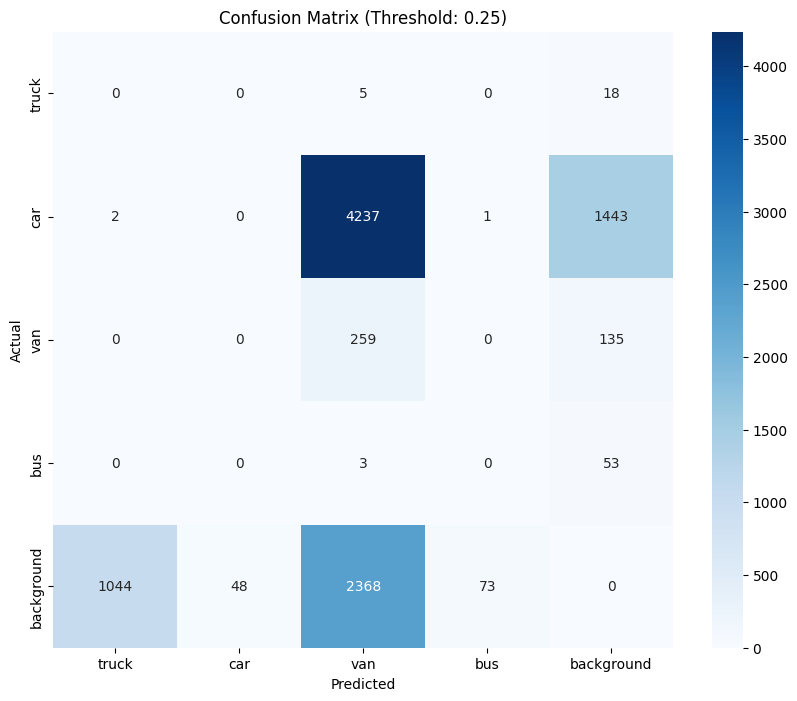

mAP@0.5: 0.0094


In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from ultralytics import YOLO
from PIL import Image
from IPython.display import display

# 1. Device and Model Setup
device = 0 if torch.cuda.is_available() else "cpu"
weights = Path("models/yolo26m.pt")
print(f"Using weights: {weights} on {device}")
model = YOLO(str(weights))

# 2. Dynamic Class Configuration
# Extract class names and count directly from the model to avoid IndexError
model_names = model.names
model_nc = len(model_names)

# Define your specific evaluation classes (as per your dataset)
class_names = ["truck", "car", "van", "bus"]
nc = len(class_names)

def yolo_label_to_xyxy(label_path, img_w, img_h):
    boxes = []
    if not label_path.exists():
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            cls = int(parts[0])
            xc, yc, w, h = map(float, parts[1:5])
            x1, y1 = (xc - w/2) * img_w, (yc - h/2) * img_h
            x2, y2 = (xc + w/2) * img_w, (yc + h/2) * img_h
            boxes.append((cls, (x1, y1, x2, y2)))
    return boxes

def iou(boxA, boxB):
    xA, yA = max(boxA[0], boxB[0]), max(boxA[1], boxB[1])
    xB, yB = min(boxA[2], boxB[2]), min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0

# 3. Load Data
test_images_dir = Path("augmentedDatasetv2/test/images")
test_labels_dir = Path("augmentedDatasetv2/test/labels")
img_paths = sorted(test_images_dir.glob("*.*"))

all_gts = {}
all_preds = {}

print("Running predictions...")
for img_path in img_paths:
    im = Image.open(img_path)
    w, h = im.size
    
    # Load GTs
    label_path = test_labels_dir / (img_path.stem + ".txt")
    all_gts[img_path.name] = yolo_label_to_xyxy(label_path, w, h)
    
    # Get Predictions
    res = model.predict(source=str(img_path), imgsz=320, device=device, conf=0.001, iou=0.5, verbose=False)
    preds = []
    boxes = res[0].boxes
    if boxes is not None:
        for b in boxes:
            box = b.xyxy.tolist()[0]
            preds.append((int(b.cls), float(b.conf), (box[0], box[1], box[2], box[3])))
    all_preds[img_path.name] = preds

# 4. Compute AP@0.5
aps = []
for c in range(nc):
    preds_list = []
    n_gt = 0
    gt_per_image = {}
    for img_name, gts in all_gts.items():
        gt_boxes = [box for cls, box in gts if cls == c]
        n_gt += len(gt_boxes)
        gt_per_image[img_name] = {"boxes": gt_boxes, "matched": [False] * len(gt_boxes)}
        for cls_p, score, box in all_preds.get(img_name, []):
            if cls_p == c:
                preds_list.append({"image": img_name, "score": score, "box": box})

    if n_gt == 0:
        aps.append(0.0); continue

    preds_list = sorted(preds_list, key=lambda x: x["score"], reverse=True)
    tp, fp = np.zeros(len(preds_list)), np.zeros(len(preds_list))

    for i, p in enumerate(preds_list):
        ginfo = gt_per_image[p["image"]]
        ious = [iou(p["box"], g) for g in ginfo["boxes"]]
        if ious:
            best_idx = np.argmax(ious)
            if ious[best_idx] >= 0.5 and not ginfo["matched"][best_idx]:
                tp[i], ginfo["matched"][best_idx] = 1, True
            else: fp[i] = 1
        else: fp[i] = 1

    tp_cum, fp_cum = np.cumsum(tp), np.cumsum(fp)
    recalls = tp_cum / n_gt
    precisions = tp_cum / (tp_cum + fp_cum + 1e-8)
    
    ap = np.mean([np.max(precisions[recalls >= rl]) if any(recalls >= rl) else 0 for rl in np.linspace(0, 1, 101)])
    aps.append(ap)

# 5. Build Confusion Matrix (FIXED Index Logic)
best_thresh = 0.25 # Can be set dynamically based on F1 optimization
conf_mat = np.zeros((model_nc + 1, model_nc + 1), dtype=int)

for img_name, gts in all_gts.items():
    preds = [p for p in all_preds.get(img_name, []) if p[1] >= best_thresh]
    gt_matched = [False] * len(gts)

    for pred_cls, _score, pred_box in sorted(preds, key=lambda x: x[1], reverse=True):
        best_iou, best_gi = 0.0, -1
        for gi, (gt_cls, gt_box) in enumerate(gts):
            if not gt_matched[gi]:
                v = iou(pred_box, gt_box)
                if v > best_iou: best_iou, best_gi = v, gi

        if best_gi >= 0 and best_iou >= 0.5:
            conf_mat[gts[best_gi][0], pred_cls] += 1
            gt_matched[best_gi] = True
        else:
            conf_mat[model_nc, pred_cls] += 1 # Background predicted as class

    for gi, (gt_cls, _) in enumerate(gts):
        if not gt_matched[gi]:
            conf_mat[gt_cls, model_nc] += 1 # Class missed (Background)

# 6. Visualization
# Filter matrix to only show the classes we care about + background
display_indices = list(range(nc)) + [model_nc]
display_labels = class_names + ["background"]
filtered_cm = conf_mat[np.ix_(display_indices, display_indices)]

cm_df = pd.DataFrame(filtered_cm, index=display_labels, columns=display_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix (Threshold: {best_thresh})")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

print(f"mAP@0.5: {np.mean(aps):.4f}")